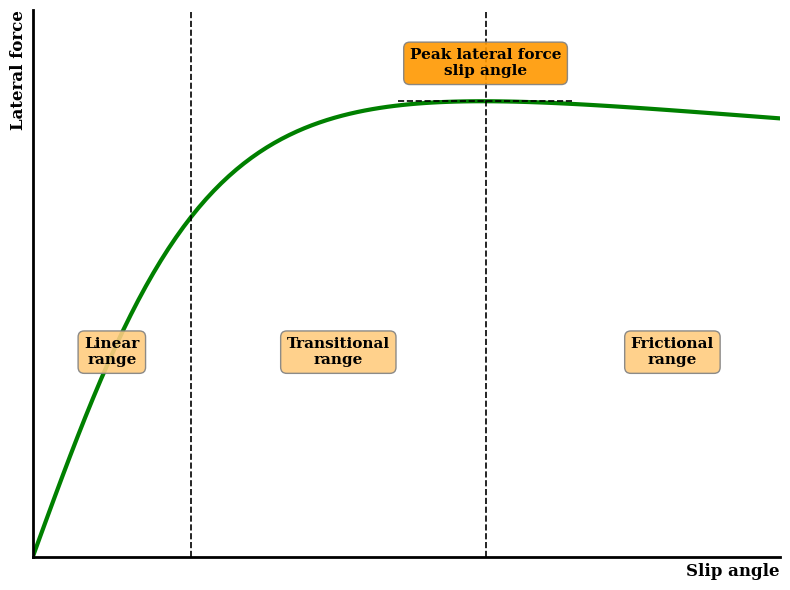

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração de estilo para artigos
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'

# Gerando os dados (Fórmula Mágica de Pacejka simplificada) - Ajustado o range de X
# Reduzindo o range para 6 para truncar a curva mais cedo, como na imagem
x = np.linspace(0, 6, 100) 
B, C, D, E = 0.5, 1.5, 1.0, 0.1
y = D * np.sin(C * np.arctan(B * x - E * (B * x - np.arctan(B * x))))

# Encontrando dinamicamente o pico da curva
idx_peak = np.argmax(y)
x_peak = x[idx_peak]
y_peak = y[idx_peak]

# Definindo o fim da zona linear (visualmente cerca de 35% do caminho até o pico)
x_lin_end = x_peak * 0.35

fig, ax = plt.subplots(figsize=(8, 6))
# Mudando a cor da curva para verde
ax.plot(x, y, color='green', linewidth=3) 

# Forçando os eixos a começarem exatamente no 0,0 e truncando o eixo x
ax.set_xlim(0, x[-1]) 
ax.set_ylim(0, y_peak * 1.2)

# Adicionando as divisões verticais nos lugares geométricos corretos
ax.axvline(x=x_lin_end, color='black', linestyle='--', linewidth=1.2)
ax.axvline(x=x_peak, color='black', linestyle='--', linewidth=1.2)

# Linha horizontal tracejada no topo do pico
ax.hlines(y=y_peak, xmin=x_peak - 0.7, xmax=x_peak + 0.7, color='black', linestyle='--', linewidth=1.2)

# Estilo das caixas de texto (removido o shadow=True que causava o erro)
box_style = dict(boxstyle="round,pad=0.4", fc="#ffcc80", ec="gray", alpha=0.9)

# Altura padronizada (Y) para as três caixas de baixo
y_text = y_peak * 0.45 

# Posicionando os textos: calculando o centro entre as linhas verticais
ax.text(x_lin_end / 2, y_text, 'Linear\nrange', ha='center', va='center', bbox=box_style, fontsize=11, fontweight='bold')
ax.text((x_lin_end + x_peak) / 2, y_text, 'Transitional\nrange', ha='center', va='center', bbox=box_style, fontsize=11, fontweight='bold')
ax.text(x_peak + 1.5, y_text, 'Frictional\nrange', ha='center', va='center', bbox=box_style, fontsize=11, fontweight='bold')

# Caixa de texto do Pico (removido o shadow=True)
ax.text(x_peak, y_peak + 0.05, 'Peak lateral force\nslip angle', ha='center', va='bottom', 
        bbox=dict(boxstyle="round,pad=0.4", fc="#ff9800", ec="gray", alpha=0.9), fontsize=11, fontweight='bold')

# Configurando os eixos para imitar a referência (Mudando as cores de blue para black)
ax.set_xlabel('Slip angle', fontsize=12, loc='right', color='black', fontweight='bold')
ax.set_ylabel('Lateral force', fontsize=12, loc='top', color='black', fontweight='bold')

# Estilização das bordas
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
# Mudando a cor da spine para black
ax.spines['left'].set_color('black') 
ax.spines['bottom'].set_linewidth(2)
# Mudando a cor da spine para black
ax.spines['bottom'].set_color('black') 
ax.set_xticks([])
ax.set_yticks([])

# Adicionando as setas nas pontas dos eixos (como no template) - Removido/Comentado
# ax.plot(1, 0, ">", transform=ax.get_xaxis_transform(), clip_on=False, color='mediumblue', markersize=8)
# ax.plot(0, 1, "^", transform=ax.get_yaxis_transform(), clip_on=False, color='mediumblue', markersize=8)

plt.tight_layout()
# plt.savefig('slip_angle_curve_corrigida.pdf', format='pdf', dpi=300) 
plt.show()